# Final Project for 50.039 Deep Learning, Y2026
## Classification of Anomalous Malicious Packets
Submitted by:
- Keagan Teo (1007779)
- Cheng Mun Yun Valerie (1007879)

Imports

In [ ]:
import joblib, json
import numpy as np

import torch
from torch.utils.data import DataLoader

from sklearn.model_selection import train_test_split

from helper_functions import one_hot_encode, get_preprocessor, run_epoch, load_data, plot_training_curves, plot_confusion_matrix, weighted_bce, print_results, train, NetworkAnomalyDetector, PacketsDataset

In [2]:
# Seed for reproducability
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


Reading the data

In [3]:
df = load_data("data/UNSW-NB15_1.csv")

/home/ubuntu/stoopidterm6/deeplearning/deeplearningsutd/helper_functions.py:185: DtypeWarning: Columns (1,3,47) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)


### Feature engineering:

#### Dropping features
- "srcip" and "dstip" are raw ip addresses that won't generalize across datasets. Behavioral patterns from IPs are already captured by the ct_ features
- "stime" and "ltime" are absolute timestamps of the packet and carries no signal on whether traffic is malicious
- "stcpb" and "dtcpb" source and destination TCP base sequence number is randomly initialized and does not help with categorization
- "sport" and "dsport" are raw port numbers and service and protocol that can be deduced from port numbers are already captured in "proto" and "service" features
- "attack_cat" is an extension of a label and should not be included in the training data

In [4]:
df.drop(["srcip", "dstip", "stime", "ltime", "stcpb", "dtcpb", "sport", "dsport", "attack_cat"], axis=1, inplace=True)

#### One Hot Encoding columns with non-numerical data:
1. "proto" - protocol of the packet (tcp, udp, etc.)
2. "state" - state of the packet
3. "service" - service of the packet (ftp, http, smtp, etc.)

In [5]:
df_ohe = one_hot_encode(df, columns=['proto_group', 'state', 'service'])

#### Training/validation/test split

We split before normalizing so that we are able to calculate the averages of only the training set, and apply the transformations to the test and validation sets to prevent information leakage
- `stratify` used to ensure that the training/validation/test datasets will have an equal proportion of class labels as the original dataset. This is especially important for anormaly detection where there is a heavy class imbalance

In [6]:
# Remove labels before processing data
y = df_ohe.pop("label").values.astype(np.float32)
X = df_ohe

In [7]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)
print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

Train: 560000 | Val: 70000 | Test: 70000


#### Normalizing numerical columns

Different columns need to be handled differently based on what information they represent and the skewedness of their data.
- `Log + StandardScalar` - for columns that are heavily skewed to the right
- `MixMaxScalar` - for columns that we know the hard boundaries for
- `Clip + Log + StandardScalar` - for columns that have extreme values that are deemed to be noise and contribute in no meaningful way to training
- `StandardScalar` - for columns that already have a roughly normal distribution

In [ ]:
preprocessor = get_preprocessor()
# Fit on train only, transform all splits
X_train = preprocessor.fit_transform(X_train).astype(np.float32)
X_val = preprocessor.transform(X_val).astype(np.float32)
X_test = preprocessor.transform(X_test).astype(np.float32)

In [9]:
INPUT_DIM = X_train.shape[1]
print(f"Input dimension after preprocessing: {INPUT_DIM}")

Input dimension after preprocessing: 73


### DataLoader

DataLoaders

In [11]:
train_dataset = PacketsDataset(X_train, y_train)
val_dataset = PacketsDataset(X_val,   y_val)
test_dataset = PacketsDataset(X_test,  y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

### Model 

Some things about our model:
- Uses He initialization for all Linear layers
- Applies a Linear -> BatchNorm -> ReLU -> Dropout for all hidden layers

In [12]:
model = NetworkAnomalyDetector(input_dim=INPUT_DIM, dropout_p=0.3).to(DEVICE)
print(model)
print(f"\nTrainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

NetworkAnomalyDetector(
  (network): Sequential(
    (0): Linear(in_features=73, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=64, out_features=32, bias=True)
    (13): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15): Dropout(p=0.3, inplace=False)
    (16): Linear(in_features=32, out_features=1, bias=True)
    (17): Sigmoid()
  )
)

Trainable parameters: 63,169


#### Loss, Optimizer, Scheduler

**Loss**: Weighted BCE — up-weights the minority malicious class by `n_benign / n_malicious` to counteract class imbalance.

In [ ]:
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
raw_ratio = n_neg / n_pos

# in case of balanced dataset, penalize misclassification of malicious packets more, since a false negative is far more costly
pos_weight_value = max(1.5, raw_ratio)

pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32).to(DEVICE)

print(f"pos_weight: {pos_weight.item():.2f}  (benign={n_neg:,}, malicious={n_pos:,})")

loss_func = lambda pred, target: weighted_bce(pred, target, pos_weight)

pos_weight: 30.51  (benign=542,228, malicious=17,772)


**Optimiser**: Adam with L2 weight decay.\
**Scheduler**: `ReduceLROnPlateau` halves the LR when val loss stagnates.

In [14]:
# Hyperparameters
LR           = 1e-3
WEIGHT_DECAY = 1e-4
NUM_EPOCHS   = 50
PATIENCE     = 7       # early stopping patience
SAVE_PATH    = 'best_model.pth'

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# Scheduler (reduce LR when validation loss plateaus)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

#### Training Loop

In [ ]:
train(model, optimizer, scheduler, train_loader, val_loader, loss_func, DEVICE, NUM_EPOCHS, PATIENCE)

Epoch [001/50]  Train Loss: 0.0790  |  Val Loss: 0.0331  |  Val F1: 0.9101  |  Val AUC: 0.9994
  ✓  Best model saved to 'best_model.pth'
Epoch [002/50]  Train Loss: 0.0414  |  Val Loss: 0.0310  |  Val F1: 0.9170  |  Val AUC: 0.9992
  ✓  Best model saved to 'best_model.pth'
Epoch [003/50]  Train Loss: 0.0383  |  Val Loss: 0.0325  |  Val F1: 0.9187  |  Val AUC: 0.9994
Epoch [004/50]  Train Loss: 0.0401  |  Val Loss: 0.0359  |  Val F1: 0.8877  |  Val AUC: 0.9993
Epoch [005/50]  Train Loss: 0.0383  |  Val Loss: 0.0336  |  Val F1: 0.9208  |  Val AUC: 0.9994
Epoch [006/50]  Train Loss: 0.0396  |  Val Loss: 0.0305  |  Val F1: 0.9014  |  Val AUC: 0.9994
  ✓  Best model saved to 'best_model.pth'
Epoch [007/50]  Train Loss: 0.0390  |  Val Loss: 0.0302  |  Val F1: 0.9092  |  Val AUC: 0.9994
  ✓  Best model saved to 'best_model.pth'
Epoch [008/50]  Train Loss: 0.0388  |  Val Loss: 0.0348  |  Val F1: 0.9093  |  Val AUC: 0.9994
Epoch [009/50]  Train Loss: 0.0390  |  Val Loss: 0.0309  |  Val F1: 0.91

#### Validation Set Evaluation

In [ ]:
val_stats = run_epoch(model=model, optimizer=optimizer, data_loader=val_loader, loss_func=loss_func, device=DEVICE, training=False)
preds_bin = (val_stats['probs'] >= 0.5).astype(int)

print_results(val_stats, preds_bin, "=== Validation Set Results ===")

=== Test Set Results ===
Loss      : 0.0302
Accuracy  : 0.9937
Precision : 0.8335
Recall    : 1.0000
F1        : 0.9092
ROC-AUC   : 0.9994


##### Training Curves

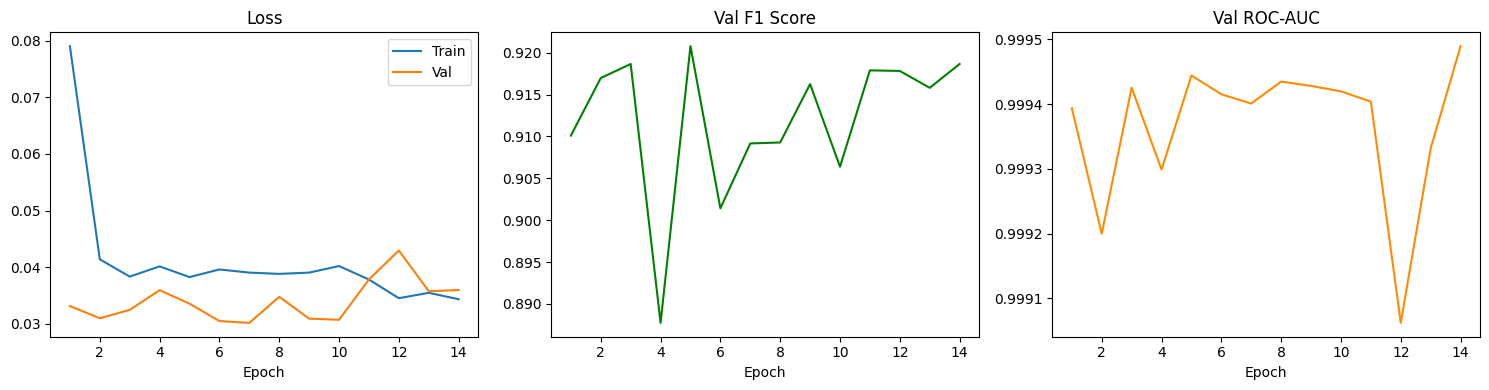

In [ ]:
plot_training_curves(history)

##### Confusion Matrix

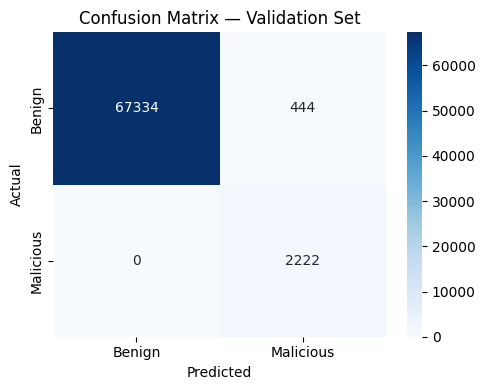

In [ ]:
plot_confusion_matrix(val_stats, preds_bin, 'Confusion Matrix — Validation Set')

#### Hyperparameter Tuning

- TODO

#### Test Set Evaluation

In [ ]:
test_stats = run_epoch(model=model, optimizer=optimizer, data_loader=test_loader, loss_func=loss_func, device=DEVICE, training=False)
preds_bin = (test_stats['probs'] >= 0.5).astype(int)

print_results(test_stats, preds_bin, "=== Test Set Results ===")

=== Test Set Results ===
Loss      : 0.0288
Accuracy  : 0.9940
Precision : 0.8410
Recall    : 1.0000
F1        : 0.9136
ROC-AUC   : 0.9995

              precision    recall  f1-score   support

      benign       1.00      0.99      1.00     67779
   malicious       0.84      1.00      0.91      2221

    accuracy                           0.99     70000
   macro avg       0.92      1.00      0.96     70000
weighted avg       0.99      0.99      0.99     70000



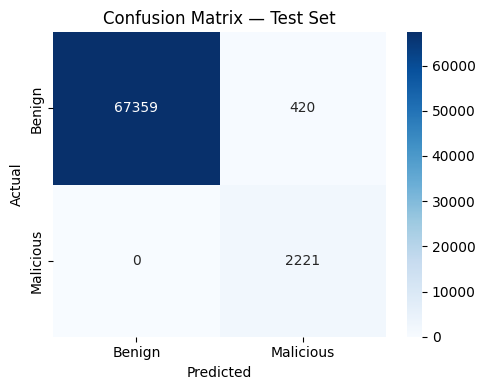

In [ ]:
plot_confusion_matrix(test_stats, preds_bin, 'Confusion Matrix — Test Set')

#### Save preprocessing artifects

In [21]:
joblib.dump(preprocessor, 'preprocessor.pkl')
print("Preprocessor saved to preprocessor.pkl")

# Save the column order that ColumnTransformer was fitted on
with open('feature_columns.json', 'w') as f:
    json.dump(list(df_ohe.columns), f)
print(f"Feature columns ({INPUT_DIM} total) saved to feature_columns.json")

Preprocessor saved to preprocessor.pkl
Feature columns (73 total) saved to feature_columns.json
